# Import Libraries

In [3]:
#add imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load and explore dataset

In [4]:
#load csv
df = pd.read_csv("tech_sales_takehome_messy.csv")
df.head()

,OrderID,OrderDate,ClientID,Region,Product,Category,SalesRep,UnitsSold,UnitPrice,Revenue
0,ORD-1000,15/01/2026,C350,Europe,SaaS CRM Platform,SaaS,Anna K,1.0,299,299
1,ORD-1001,2026-01-14,C704,LATAM,SaaS CRM Platform,SaaS,John D.,18.0,99,1782
2,ORD-1002,2026-01-12,C617,North America,Cloud Storage Pro,Cloud,NaN,7.0,199,"1,393"
3,ORD-1003,2026-03-25,C325,LATAM,AI Analytics Suite,AI,DAVID T,18.0,499,8982
4,ORD-1004,2026-01-01,C448,APAC,CyberShield Security,Security,Anna K,6.0,499,2994


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   OrderID    155 non-null    object 
 1   OrderDate  155 non-null    object 
 2   ClientID   155 non-null    object 
 3   Region     144 non-null    object 
 4   Product    155 non-null    object 
 5   Category   155 non-null    object 
 6   SalesRep   145 non-null    object 
 7   UnitsSold  144 non-null    float64
 8   UnitPrice  155 non-null    object 
 9   Revenue    155 non-null    object 
dtypes: float64(1), object(9)
memory usage: 12.2+ KB


In [6]:
df.isna().sum() / len(df)

,0
OrderID,0.000000
OrderDate,0.000000
ClientID,0.000000
Region,0.070968
Product,0.000000
Category,0.000000
SalesRep,0.064516
UnitsSold,0.070968
UnitPrice,0.000000
Revenue,0.000000


# Convert and Normalize Date to appropriate Date type

In [7]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'], format='mixed', dayfirst=True, errors='coerce')

# df.info()

# Check the numeric data for inconsistency

In [8]:
numeric_data = ["UnitsSold","UnitPrice","Revenue"]

for col in numeric_data:

  print(df[col].unique())


[ 1. 18.  7.  6.  4.  9.  3. 12. nan  8. 13. 19. 14. 17. 16. 11.  5. 10.
 20. 15.  2.]
['299' '99' '199' '499' '$999' '$499' '$299' '999' '$99' '$199']
['299' '1782' '1,393' '8982' '2994' '396' '891' '2997' '297' '1996' '3588'
 '2,392' '3887' '3493' '7992' '9481' '13986' '5,083' '5382' '1196' '17982'
 '3,588' '1497' '15984' '6993' '5988' '897' '3383' '18981' '1485' '796'
 '2786' '1,782' '6986' '1,287' '15,984' '594' '3996' '2189' '4990' '1,881'
 '1188' '1495' '8991' '4186' '1791' '598' '2,990' '792' '1,592' '5489'
 '4,485' '3,493' '8483' '5994' '2093' '1089' '6,986' '12987' '6,993'
 '16983' '1592' '1980' '6487' '99' '14985' '2392' '2691' '2,587' '10989'
 '3980' '499' '4995' '5,489' '999' '198' '1881' '7,485' '4,491' '7984'
 '2587' '5,988' '2,691' '1,089' '8,991' '2495' '398' '1998' '990' '495'
 '998' '597' '4784' '11,988' '1584']


# Removing Inconsistencies and Normalizing Data

In [9]:
df['UnitPrice'] = df['UnitPrice'].str.replace("$", "")
df['Revenue'] =  df['Revenue'].str.replace(",", "")
for col in numeric_data:
  df[col] = df[col].apply(pd.to_numeric, errors='coerce')

In [10]:


for col in numeric_data:

  print(df[col].unique())

[ 1. 18.  7.  6.  4.  9.  3. 12. nan  8. 13. 19. 14. 17. 16. 11.  5. 10.
 20. 15.  2.]
[299  99 199 499 999]
[  299  1782  1393  8982  2994   396   891  2997   297  1996  3588  2392
  3887  3493  7992  9481 13986  5083  5382  1196 17982  1497 15984  6993
  5988   897  3383 18981  1485   796  2786  6986  1287   594  3996  2189
  4990  1881  1188  1495  8991  4186  1791   598  2990   792  1592  5489
  4485  8483  5994  2093  1089 12987 16983  1980  6487    99 14985  2691
  2587 10989  3980   499  4995   999   198  7485  4491  7984  2495   398
  1998   990   495   998   597  4784 11988  1584]


In [11]:
df['UnitPrice'].unique()
df['Revenue'].unique()

array([  299,  1782,  1393,  8982,  2994,   396,   891,  2997,   297,
        1996,  3588,  2392,  3887,  3493,  7992,  9481, 13986,  5083,
        5382,  1196, 17982,  1497, 15984,  6993,  5988,   897,  3383,
       18981,  1485,   796,  2786,  6986,  1287,   594,  3996,  2189,
        4990,  1881,  1188,  1495,  8991,  4186,  1791,   598,  2990,
         792,  1592,  5489,  4485,  8483,  5994,  2093,  1089, 12987,
       16983,  1980,  6487,    99, 14985,  2691,  2587, 10989,  3980,
         499,  4995,   999,   198,  7485,  4491,  7984,  2495,   398,
        1998,   990,   495,   998,   597,  4784, 11988,  1584])

In [12]:
df['UnitsSold']

,UnitsSold
0,1.0
1,18.0
2,7.0
3,18.0
4,6.0
...,...
150,NaN
151,3.0
152,11.0
153,8.0


# Checking for rows with 0 values in Revenue and UnitPrice

In [13]:
df[df['Revenue'] == 0]
df[df['UnitPrice'] == 0]

,OrderID,OrderDate,ClientID,Region,Product,Category,SalesRep,UnitsSold,UnitPrice,Revenue


In [14]:
df[['UnitsSold','UnitPrice','Revenue']].describe()

,UnitsSold,UnitPrice,Revenue
count,144.000000,155.000000,155.000000
mean,9.958333,432.548387,4371.948387
std,5.540537,326.587515,4524.705458
min,1.000000,99.000000,99.000000
25%,5.000000,199.000000,1192.000000
50%,9.000000,299.000000,2691.000000
75%,14.000000,499.000000,5991.000000
max,20.000000,999.000000,18981.000000


# Check for mismatches/inconsistencies in the naming of regions


In [15]:
df['Region'].unique()

array(['Europe', 'LATAM', 'North America', 'APAC', nan, 'europe',
       'north america', 'N. America', 'EU', 'South America',
       'Asia Pacific', 'LatAm', 'apac'], dtype=object)

# Standerdizing region names

In [16]:
df['Region'] = df['Region'].replace({
    'europe': 'Europe',
    'EU': 'Europe',
    'LatAm': 'Latam',
    'LATAM': 'Latam',
    'APAC': 'Asia Pacific',
    'apac': 'Asia Pacific',
    'north america': 'North America',
    'N. America': 'North America'
})

## There were no specific instructions to group Latam and North America, or any indication that they overlap, so i handled them seprately.

# Verifying naming Consistency in region

In [17]:
df['Region'].unique()

array(['Europe', 'Latam', 'North America', 'Asia Pacific', nan,
       'South America'], dtype=object)

# Checking for inconsistencies

In [18]:
descriptive_data = ["Product",	"Category", "SalesRep"]

for col in descriptive_data:
  df[col] = df[col].str.strip()
  print(df[col].unique())

['SaaS CRM Platform' 'Cloud Storage Pro' 'AI Analytics Suite'
 'CyberShield Security' 'IoT Device Manager' 'DevOps Automator']
['SaaS' 'Cloud' 'AI' 'Security' 'IoT' 'DevOps']
['Anna K' 'John D.' nan 'DAVID T' 'michael brown' 'Emily R' 'Sara L.']


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   OrderID    155 non-null    object        
 1   OrderDate  155 non-null    datetime64[ns]
 2   ClientID   155 non-null    object        
 3   Region     144 non-null    object        
 4   Product    155 non-null    object        
 5   Category   155 non-null    object        
 6   SalesRep   145 non-null    object        
 7   UnitsSold  144 non-null    float64       
 8   UnitPrice  155 non-null    int64         
 9   Revenue    155 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(6)
memory usage: 12.2+ KB


# Checking For Missing Values

In [20]:
df.isna().sum() / len(df)

,0
OrderID,0.000000
OrderDate,0.000000
ClientID,0.000000
Region,0.070968
Product,0.000000
Category,0.000000
SalesRep,0.064516
UnitsSold,0.070968
UnitPrice,0.000000
Revenue,0.000000


## Checking if there is any relationship between missing region and other columns

In [21]:
null_regions = df[df['Region'].isna()]
null_regions

,OrderID,OrderDate,ClientID,Region,Product,Category,SalesRep,UnitsSold,UnitPrice,Revenue
8,ORD-1008,2026-04-01,C777,NaN,AI Analytics Suite,AI,michael brown,3.0,99,297
10,ORD-1010,2026-01-21,C314,NaN,CyberShield Security,Security,Emily R,12.0,299,3588
23,ORD-1023,2026-03-06,C961,NaN,AI Analytics Suite,AI,Anna K,4.0,299,1196
24,ORD-1024,2026-01-21,C100,NaN,CyberShield Security,Security,Sara L.,18.0,999,17982
33,ORD-1033,2026-01-17,C584,NaN,IoT Device Manager,IoT,Sara L.,19.0,999,18981
59,ORD-1059,2026-01-06,C915,NaN,AI Analytics Suite,AI,michael brown,10.0,299,2990
75,ORD-1075,2026-01-27,C721,NaN,CyberShield Security,Security,NaN,14.0,999,13986
79,ORD-1079,2026-03-02,C566,NaN,AI Analytics Suite,AI,Emily R,20.0,99,1980
93,ORD-1093,2026-03-04,C444,NaN,DevOps Automator,DevOps,Emily R,1.0,499,499
112,ORD-1112,2026-03-18,C110,NaN,CyberShield Security,Security,John D.,9.0,999,8991


## There are no obvious relationships between missing region and any other categories; therefore i am imputing the values with 'unknown'

In [22]:
df['Region'] = df['Region'].fillna('Unknown')

## Checking if there is any relationship between missing Sales Rep and other columns

In [23]:
null_sale_rep = df[df['SalesRep'].isna()]
null_sale_rep

,OrderID,OrderDate,ClientID,Region,Product,Category,SalesRep,UnitsSold,UnitPrice,Revenue
2,ORD-1002,2026-01-12,C617,North America,Cloud Storage Pro,Cloud,NaN,7.0,199,1393
5,ORD-1005,2026-02-13,C489,North America,AI Analytics Suite,AI,NaN,4.0,99,396
60,ORD-1060,2026-03-29,C462,Latam,AI Analytics Suite,AI,NaN,8.0,99,792
70,ORD-1070,2026-03-10,C541,North America,IoT Device Manager,IoT,NaN,7.0,299,2093
75,ORD-1075,2026-01-27,C721,Unknown,CyberShield Security,Security,NaN,14.0,999,13986
91,ORD-1091,2026-03-03,C405,Latam,DevOps Automator,DevOps,NaN,1.0,299,299
97,ORD-1097,2026-02-11,C384,Latam,DevOps Automator,DevOps,NaN,11.0,499,5489
101,ORD-1101,2026-03-01,C271,North America,AI Analytics Suite,AI,NaN,9.0,299,2691
146,ORD-1146,2026-01-07,C662,Europe,DevOps Automator,DevOps,NaN,7.0,299,2093
147,ORD-1147,2026-03-31,C129,Europe,DevOps Automator,DevOps,NaN,16.0,99,1584


## There are no obvious relationships between missing Sales rep and any other categories; therefore i am imputing the values with 'unknown'

In [24]:
df['SalesRep'] = df['SalesRep'].fillna('Unknown')

In [25]:
null_sold_unit = df[df['UnitsSold'].isna()]
null_sold_unit

,OrderID,OrderDate,ClientID,Region,Product,Category,SalesRep,UnitsSold,UnitPrice,Revenue
12,ORD-1012,2026-02-01,C488,Asia Pacific,SaaS CRM Platform,SaaS,Emily R,NaN,499,2994
35,ORD-1035,2026-02-22,C789,North America,DevOps Automator,DevOps,John D.,NaN,99,1485
48,ORD-1048,2026-03-24,C423,North America,SaaS CRM Platform,SaaS,John D.,NaN,499,4990
56,ORD-1056,2026-03-23,C859,Latam,AI Analytics Suite,AI,DAVID T,NaN,199,1791
58,ORD-1058,2026-03-11,C696,Europe,AI Analytics Suite,AI,Sara L.,NaN,299,598
64,ORD-1064,2026-01-26,C412,Europe,AI Analytics Suite,AI,Anna K,NaN,299,4485
73,ORD-1073,2026-01-25,C793,Europe,AI Analytics Suite,AI,DAVID T,NaN,499,6986
90,ORD-1090,2026-02-23,C812,North America,AI Analytics Suite,AI,DAVID T,NaN,999,12987
127,ORD-1127,2026-02-27,C980,Latam,DevOps Automator,DevOps,michael brown,NaN,299,4485
144,ORD-1144,2026-03-07,C573,Latam,DevOps Automator,DevOps,John D.,NaN,999,999


## Validate that revenue consistency

In [26]:
df['CalculatedRevenue'] = df['UnitsSold'] * df['UnitPrice']
df['CalculatedRevenue']
df['RevenueDifference'] = df['Revenue'] - df['CalculatedRevenue']
df['RevenueDifference'].describe()

,RevenueDifference
count,144.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


## checking for rows with inconsistencies

In [27]:
inconsistent = df[df['RevenueDifference'].abs() > 0.01]
inconsistent

,OrderID,OrderDate,ClientID,Region,Product,Category,SalesRep,UnitsSold,UnitPrice,Revenue,CalculatedRevenue,RevenueDifference


In [28]:
inconsistency_rate = len(inconsistent) / len(df) * 100
print(f"The inconsistency rate is {inconsistency_rate:.2f}%")

The inconsistency rate is 0.00%


## Relationship between Revenue, UnitsSold, and UnitPrice is perfectly stable across non-missing data, so i am imputing the missing values with revenue / unit price

In [29]:
df['UnitsSold'] = df['UnitsSold'].fillna((df['Revenue'] / df['UnitPrice']).round())
df['UnitsSold'] = df['UnitsSold'].astype(int)

In [30]:
null_rev = df[df['RevenueDifference'].isna()]
null_rev

,OrderID,OrderDate,ClientID,Region,Product,Category,SalesRep,UnitsSold,UnitPrice,Revenue,CalculatedRevenue,RevenueDifference
12,ORD-1012,2026-02-01,C488,Asia Pacific,SaaS CRM Platform,SaaS,Emily R,6,499,2994,NaN,NaN
35,ORD-1035,2026-02-22,C789,North America,DevOps Automator,DevOps,John D.,15,99,1485,NaN,NaN
48,ORD-1048,2026-03-24,C423,North America,SaaS CRM Platform,SaaS,John D.,10,499,4990,NaN,NaN
56,ORD-1056,2026-03-23,C859,Latam,AI Analytics Suite,AI,DAVID T,9,199,1791,NaN,NaN
58,ORD-1058,2026-03-11,C696,Europe,AI Analytics Suite,AI,Sara L.,2,299,598,NaN,NaN
64,ORD-1064,2026-01-26,C412,Europe,AI Analytics Suite,AI,Anna K,15,299,4485,NaN,NaN
73,ORD-1073,2026-01-25,C793,Europe,AI Analytics Suite,AI,DAVID T,14,499,6986,NaN,NaN
90,ORD-1090,2026-02-23,C812,North America,AI Analytics Suite,AI,DAVID T,13,999,12987,NaN,NaN
127,ORD-1127,2026-02-27,C980,Latam,DevOps Automator,DevOps,michael brown,15,299,4485,NaN,NaN
144,ORD-1144,2026-03-07,C573,Latam,DevOps Automator,DevOps,John D.,1,999,999,NaN,NaN


In [31]:
df.isna().sum() / len(df)

,0
OrderID,0.000000
OrderDate,0.000000
ClientID,0.000000
Region,0.000000
Product,0.000000
Category,0.000000
SalesRep,0.000000
UnitsSold,0.000000
UnitPrice,0.000000
Revenue,0.000000


In [32]:
df.head()

,OrderID,OrderDate,ClientID,Region,Product,Category,SalesRep,UnitsSold,UnitPrice,Revenue,CalculatedRevenue,RevenueDifference
0,ORD-1000,2026-01-15,C350,Europe,SaaS CRM Platform,SaaS,Anna K,1,299,299,299.0,0.0
1,ORD-1001,2026-01-14,C704,Latam,SaaS CRM Platform,SaaS,John D.,18,99,1782,1782.0,0.0
2,ORD-1002,2026-01-12,C617,North America,Cloud Storage Pro,Cloud,Unknown,7,199,1393,1393.0,0.0
3,ORD-1003,2026-03-25,C325,Latam,AI Analytics Suite,AI,DAVID T,18,499,8982,8982.0,0.0
4,ORD-1004,2026-01-01,C448,Asia Pacific,CyberShield Security,Security,Anna K,6,499,2994,2994.0,0.0


## Checking for duplicate values

In [33]:
df_duplicates = df['OrderID'].duplicated().sum()
print("Number of duplicate rows:", df_duplicates)

Number of duplicate rows: 5


Removing duplicate rows from the DataFrame based on 'OrderID'. This ensures df remains a DataFrame and drops the entire row if OrderID is a duplicate

In [34]:
df = df.drop_duplicates(subset=['OrderID'])

# Verify that there are no more duplicates in the 'OrderID' column
df_duplicates_after_removal = df['OrderID'].duplicated().sum()
print("Number of duplicate rows after removal:", df_duplicates_after_removal)

Number of duplicate rows after removal: 0


In [35]:
# make copy for data analysis
df_clean = df.copy()

Last_date = df_clean['OrderDate'].max()
print(Last_date)



2026-04-01 00:00:00


Filtered OrderDate column because I discovered one transaction in April

In [36]:
# Filter strictly to Q1 2026 (January–March)
df_clean = df_clean[df_clean['OrderDate'] < '2026-04-01']

In [37]:
# read top rows to verify df copy is valid
df_clean.head()

,OrderID,OrderDate,ClientID,Region,Product,Category,SalesRep,UnitsSold,UnitPrice,Revenue,CalculatedRevenue,RevenueDifference
0,ORD-1000,2026-01-15,C350,Europe,SaaS CRM Platform,SaaS,Anna K,1,299,299,299.0,0.0
1,ORD-1001,2026-01-14,C704,Latam,SaaS CRM Platform,SaaS,John D.,18,99,1782,1782.0,0.0
2,ORD-1002,2026-01-12,C617,North America,Cloud Storage Pro,Cloud,Unknown,7,199,1393,1393.0,0.0
3,ORD-1003,2026-03-25,C325,Latam,AI Analytics Suite,AI,DAVID T,18,499,8982,8982.0,0.0
4,ORD-1004,2026-01-01,C448,Asia Pacific,CyberShield Security,Security,Anna K,6,499,2994,2994.0,0.0


Core Kpi's

In [38]:
total_revenue = df_clean['Revenue'].sum()
unknown_revenue = df_clean[df_clean['Region'] == 'Unknown']['Revenue'].sum()
percentage_unknown = (unknown_revenue / total_revenue) * 100

most_purchased_category = df_clean.groupby('Category')['Revenue'].sum().reset_index().sort_values(by="Revenue", ascending=False)#.head(1)
highest_revenue_sales_rep = df_clean.groupby('SalesRep')['Revenue'].sum().reset_index().sort_values(by="Revenue", ascending=False).head(1)


print(f"Total revenue:${total_revenue:.2f}")
print(f"Unknown region revenue: ${unknown_revenue}")
print(f"Percentage of total revenue: {percentage_unknown:.2f}%")
print(most_purchased_category)
print(highest_revenue_sales_rep)
print(f"The sales rep that generated the highest revenue was {highest_revenue_sales_rep['SalesRep'].iloc[0]} with {highest_revenue_sales_rep['Revenue'].iloc[0]}")

Total revenue:$660398.00
Unknown region revenue: $71975
Percentage of total revenue: 10.90%
   Category  Revenue
0        AI   190310
5  Security   126109
3       IoT   116943
1     Cloud    90934
2    DevOps    76393
4      SaaS    59709
  SalesRep  Revenue
3  John D.   156858
The sales rep that generated the highest revenue was John D. with 156858


In [39]:
product_that_sold_the_most = df_clean.groupby('Product')['UnitsSold'].sum().reset_index().sort_values(by="UnitsSold", ascending=False)
product_that_sold_the_most

,Product,UnitsSold
0,AI Analytics Suite,390
2,CyberShield Security,291
4,IoT Device Manager,257
3,DevOps Automator,207
5,SaaS CRM Platform,191
1,Cloud Storage Pro,166


In [40]:
most_sold_product_sales_rep = df_clean.groupby('SalesRep')[['UnitsSold', 'Product']].sum().reset_index().sort_values(by="UnitsSold", ascending=False)
most_sold_product_sales_rep
most_sold_product_sales_rep

,SalesRep,UnitsSold,Product
3,John D.,342,SaaS CRM PlatformSaaS CRM PlatformCyberShield ...
6,michael brown,250,DevOps AutomatorCyberShield SecurityCloud Stor...
1,DAVID T,240,AI Analytics SuiteCyberShield SecurityCloud St...
2,Emily R,219,Cloud Storage ProCyberShield SecuritySaaS CRM ...
4,Sara L.,184,SaaS CRM PlatformCyberShield SecurityIoT Devic...
0,Anna K,183,SaaS CRM PlatformCyberShield SecuritySaaS CRM ...
5,Unknown,84,Cloud Storage ProAI Analytics SuiteAI Analytic...


In [41]:
# total revenue by product
total_revenue_by_product = df_clean.groupby('Product')['Revenue'].sum().reset_index().sort_values(by="Revenue", ascending=False)
total_revenue_by_product

,Product,Revenue
0,AI Analytics Suite,190310
2,CyberShield Security,126109
4,IoT Device Manager,116943
1,Cloud Storage Pro,90934
3,DevOps Automator,76393
5,SaaS CRM Platform,59709


In [42]:
# total revenue by  category
total_revenue_by_category = df_clean.groupby('Category')['Revenue'].sum().reset_index().sort_values(by="Revenue", ascending=False)
total_revenue_by_category

,Category,Revenue
0,AI,190310
5,Security,126109
3,IoT,116943
1,Cloud,90934
2,DevOps,76393
4,SaaS,59709


In [43]:
# Which region generates the most revenue?
total_revenue_by_region = df_clean.groupby('Region')['Revenue'].sum().reset_index().sort_values(by="Revenue", ascending=False)
total_revenue_by_region

,Region,Revenue
1,Europe,174884
0,Asia Pacific,166390
3,North America,129066
2,Latam,117586
5,Unknown,71975
4,South America,497


<Figure size 1200x600 with 0 Axes>

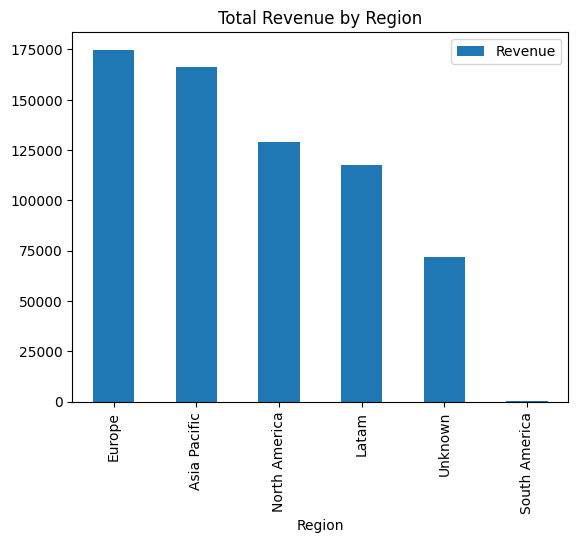

In [44]:
plt.figure(figsize=(12, 6))

total_revenue_by_region.plot(x='Region', y='Revenue', kind='bar')
plt.title('Total Revenue by Region')
plt.show()

In [45]:
revenue_in_south_america = df_clean[df_clean['Region'] == 'South America'].groupby('Category')['Revenue'].sum().reset_index().sort_values(by="Revenue", ascending=False)
revenue_in_south_america

,Category,Revenue
1,Security,398
0,SaaS,99


In [46]:
# time series
df_clean['Month'] = df_clean['OrderDate'].dt.to_period('M')

time_series = df_clean.groupby('Month')['Revenue'].sum().reset_index()
time_series



,Month,Revenue
0,2026-01,236474
1,2026-02,210058
2,2026-03,213866


<Figure size 1200x600 with 0 Axes>

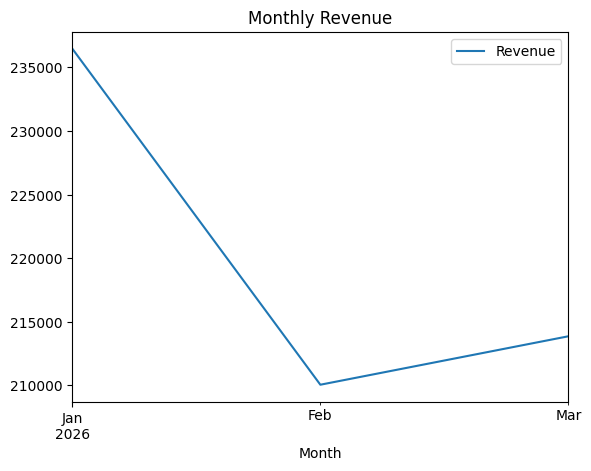

In [47]:
plt.figure(figsize=(12, 6))
time_series.plot(x='Month', y='Revenue', kind='line')
plt.title('Monthly Revenue')
plt.show()

In [112]:
# save file for sql querying and tableau visualization
df.to_csv("tech_sales_takehome_clean_2.csv",
          index=False,
          encoding='utf-8')
#





# Summary of cleaning steps
First i imported the required libarires
then i load the raw data (csv file), and displayed the first 5 rows; then i use df.info() to check and confirm the data types
After that i convert the date to the correct date format datetimeNS, then i check the numerical data for discrepencies,
after this i removed the $ and , signs so the numerical fields could be used for calculations and visualizations #
confirm that the changes were applyed
then i converted them to numeric type
I then chehcked the region fofr uniqueness, i found some inconsistent naming style, so i normalized/standerdized it
check uniqness of the rest of the data to make sure there were no inconsistencies ; the verified the data one last time
then i proceeded to check for null values; Region and SalesRep  had missing values of 7% and 6.4% respectively
I created a data frame to check the missing values and if there were any correlations
There were no strong correlation between missing region and any of the other data , same applies to SalesRep and Units Sold
so i imputed the missing data in SalesRep and Region with unknown;
with this there were no longer missing values or inconsistencies in the data
i delete rows with negative values in UnitPrice, Unitsold, and Revenue
next i checked for duplicated , there were 4 duplicate values found, so i dropped them
then i calculated the core kpi's and other metric
saved the cleaned data in a csv file

# EXECUTIVE SUMMARY

In Q1 the revenue totaled $`660,398`, `AI` generated a revenue of $`190,310` accounting for (28.8%) of the total revenue , `Security` generated the second highest revenue amounting to $`126,109` which was (19%) of the total revenue , both accounted for almost 50% of the total revenue,  while the category with the least revenue was `Saas` generating a revenue of $`59,709` accounting for just (9%) of the total revenue.

`Europe` was the region with the most revenue totaling $`174,884` which was (26.4%) of the total revenue, closely followed by `Asia Pacific` which generated a total of $`166,390`, accounting for (25.1%). However, `South America` did significantly worse in comparison to other regions with a total revenue of $`497` (< 0.1%) of total revenue. This is warrants further investigation to determine whether this reflects true market performance or data quality issues.

The sales rep with the most amount of sales was `John D.` who generated a total revenue of $`156,858` acounting for (23.7%) of the total revenue Generated.

Missing `Regions` and `Sales rep` information accounted for 8% and 7% respectively of the total data. Revenue totaling $`71,975` accounting for(10.8%) of the total revenue was recorded with unknown region, negatively impacting regional performance.

There was downward decrement in total revenue per month with `January` generating the most revenue at $`236,474`, then a dip in `February` totaling $`210,058`, and again a slight rise in `March` at $`213,866`

### Recommended Actions & insights
- Ensure validation for all fields, as this will limit the amount of data lost during analysis and will lead to more accurate and reliable performance anlysis like (region and sales rep)
- Investigate zero revenue months, to determine if it was logging error or operational
- Optimize focus towards underperforming regions and products



In [62]:
df_clean[df_clean['Month'] == '2026-04']

,OrderID,OrderDate,ClientID,Region,Product,Category,SalesRep,UnitsSold,UnitPrice,Revenue,CalculatedRevenue,RevenueDifference,Month
8,ORD-1008,2026-04-01,C777,Unknown,AI Analytics Suite,AI,michael brown,3.0,99,297,297.0,0.0,2026-04


10.898730765386935